In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [81]:
rc_record = np.load('runs/cae_steer/2026_02_03_17_55_43/rc_records.npy', allow_pickle=True).item()

In [82]:
rc = rc_record[100]

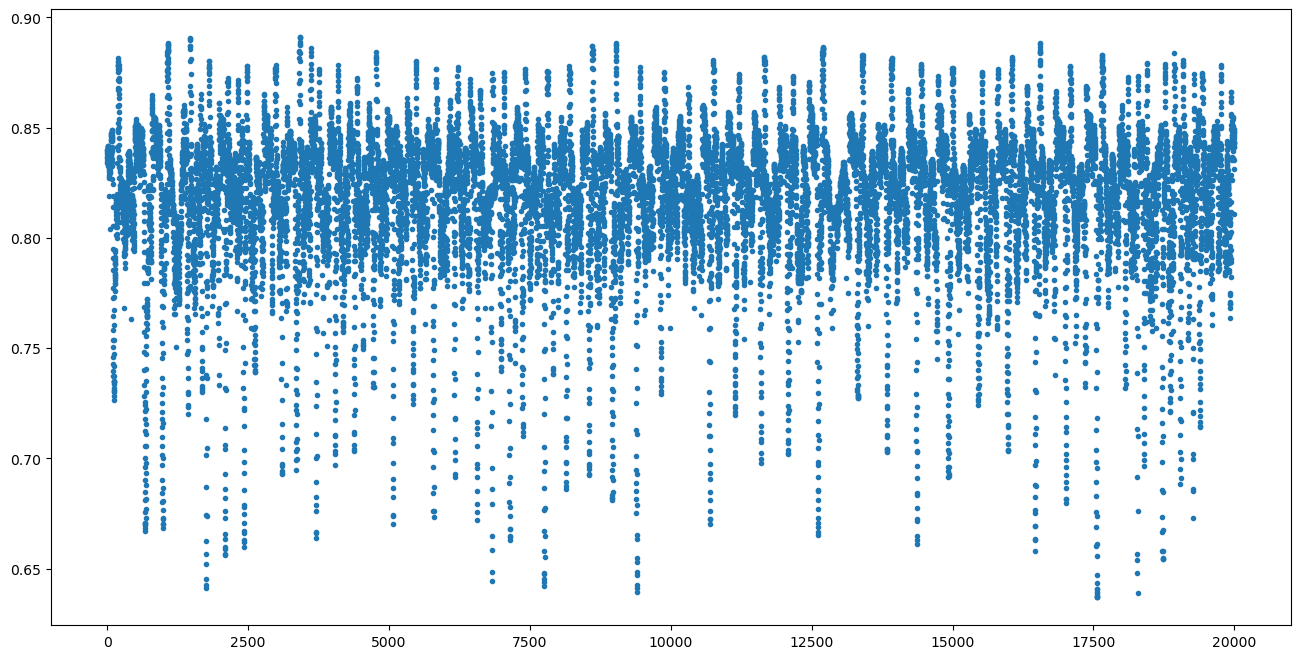

In [83]:
plt.figure(figsize=(16,8))
plt.plot(range(len(rc)), rc, '.')

In [20]:
rc_data_array = np.array(rc_data[0])

In [21]:
rc_data_array.shape

(22000,)

In [37]:
rc_data_array.mean()

np.float32(0.7627825)

In [59]:
k = 10

In [60]:
curved_rc_data = 1 / (1 + np.exp(-k*(rc_data_array - rc_data_array.mean())))

In [61]:
curved_rc_data.shape

(22000,)

In [41]:
import matplotlib.pyplot as plt

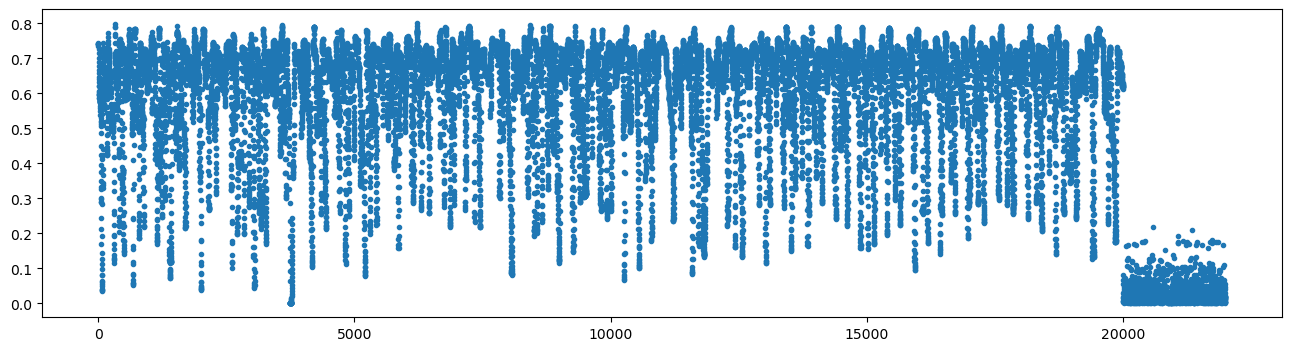

In [62]:
plt.figure(figsize=(16,4))
plt.plot(curved_rc_data, '.')

In [63]:
np.save('curved_rc_data.npy', curved_rc_data)

## Collected data preprocessing

In [1]:
import cv2
import matplotlib.pyplot as plt
import pandas
from pathlib import Path
import pickle
import numpy as np

In [2]:
image = cv2.imread('newdata/normal/images/1.jpg')

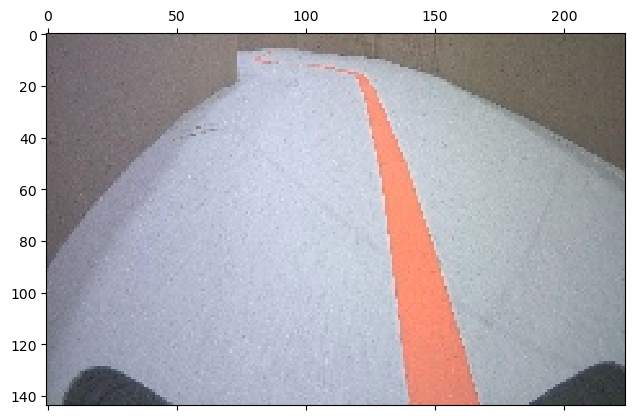

In [3]:
plt.matshow(image)

In [2]:
def load_data(data_folder):
    data_path = Path(data_folder)
    csv = pandas.read_csv(data_path / 'labels.csv')
    image_list = []
    steer_list = []
    for line in csv.itertuples():
        idx, filename, steer, throttle = line
        image = cv2.imread(str(data_path / 'images' / filename))
        image_list.append(image)
        steer_list.append(steer)

    return {'images' : np.array(image_list), 'steer' : np.array(steer_list)}
    

In [6]:
all_data = {'normal' : load_data('newdata/normal'),
            'zigzag' : load_data('newdata/hitwall1'),
            'hitwall' : load_data('newdata/hitwall2')}

In [7]:
with open('data/newdata.pkl', 'wb') as f:
    pickle.dump(all_data, f)

## Convert CNN to ONNX

In [1]:
import torch
from models import CNN
from pathlib import Path

In [14]:
model_folder = Path('runs/cnn/noise2000_500_500')

In [15]:
model = CNN()
model.load_state_dict(torch.load(model_folder / 'best.pt', weights_only=True))

<All keys matched successfully>

In [16]:
dummy = torch.randn(1, 144, 224, 3)
torch.onnx.export(
    model,
    dummy,
    model_folder / "best.onnx",
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["image"],
    output_names=["steer"]
)


W0120 16:02:56.955000 2032434 site-packages/torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 17},
            producer_name='pytorch',
            producer_version='2.9.1',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"image"<FLOAT,[1,144,224,3]>
            ),
            outputs=(
                %"steer"<FLOAT,[1,1]>
            ),
            initializers=(
                %"features.0.bias"<FLOAT,[24]>{TorchTensor(...)},
                %"features.2.bias"<FLOAT,[36]>{TorchTensor(...)},
                %"features.4.bias"<FLOAT,[48]>{TorchTensor(...)},
                %"features.6.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"features.8.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"classifier.0.bias"<FLOAT,[100]>{TorchTensor(...)},
                %"classifier.2.bias"<FLOAT,[50]>{TorchTensor(...)},
                %"classifier.4.weight"<FLOAT,[10,50]>{TorchTensor(

## Generate data for critic

In [9]:
import numpy as np
from pathlib import Path
import json
import pickle

In [4]:
result_folder = Path('runs/cae/2026_01_20_11_37_47')

In [5]:
with open(result_folder / 'run.json', 'r') as f:
    config = json.load(f)

In [6]:
lam = 1

In [18]:
with open(result_folder / f"{lam}_{config['batch_size']}_0.0005" / "rc_records.npy", 'rb') as f:
    all_rc_data = np.load(f, allow_pickle=True).item()

In [19]:
rc_data = all_rc_data[max(all_rc_data.keys())][0]

In [20]:
with open( "data/newdata.pkl", 'rb') as f:
    training_data = pickle.load(f)

In [ ]:
normal_data = training_data['normal']

In [22]:
normal_rc_data = rc_data[:20000]

In [23]:
sorted_idxs = np.argsort(normal_rc_data)

In [24]:
selected_idxs = sorted_idxs[:15000]

In [25]:
selected_images = normal_data['images'][selected_idxs]
selected_steers = normal_data['steer'][selected_idxs]

In [27]:
makeup_steers = np.random.rand(*selected_steers.shape) * 2 - 1

In [35]:
images = np.concatenate([selected_images, selected_images])
steers = np.concatenate([selected_steers, makeup_steers])
labels = np.concatenate([np.ones(*selected_steers.shape), np.zeros(*makeup_steers.shape)])

In [36]:
critic_training_data = {
   "images" : images,
   "steers" : steers,
   "labels" : labels
}

In [37]:
with open('data/critic_training_data.pkl', 'wb') as f:
    pickle.dump(critic_training_data, f)

## Eval Critic

In [1]:
import numpy as np
import pickle
import random
import matplotlib.pyplot as plt
from models import Critic
import torch

In [2]:
data_path = 'data/cae_training_data.pkl'

In [3]:
with open(data_path, 'rb') as f:
    data = pickle.load(f)

In [4]:
device = torch.device('cuda')

In [11]:
images = torch.from_numpy(np.concatenate([v['images'] for k,v in data.items()])).to(device, dtype=torch.float32)
steers = torch.from_numpy(np.concatenate([v['steer'] for k,v in data.items()])).unsqueeze(1).to(device, dtype=torch.float32)

In [13]:
model = Critic().to(device)
model.load_state_dict(torch.load('runs/critic/2026_01_22_10_53_43/best.pt'))

<All keys matched successfully>

In [14]:
preds = model(images, steers)

In [55]:
image, steer, pred = random.choice(list(zip(images, steers, preds)))

Steer angle 1.000
Normal confidence 0.000


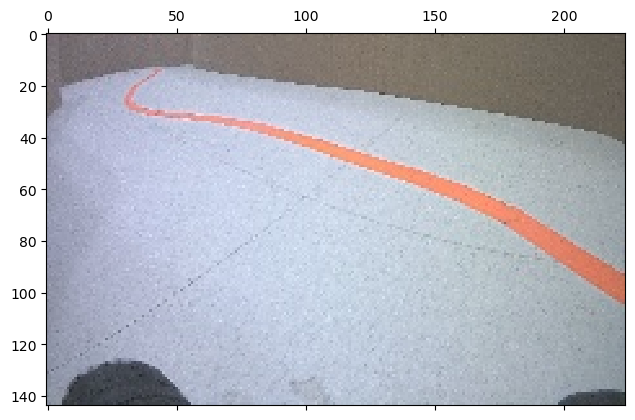

In [56]:
plt.matshow(image.detach().cpu().int().numpy())
print(f'Steer angle {steer.item():.3f}')
print(f'Normal confidence {pred.item():.3f}')

In [57]:
torch.mean(preds * preds)

tensor(0.1975, device='cuda:0', grad_fn=<MeanBackward0>)

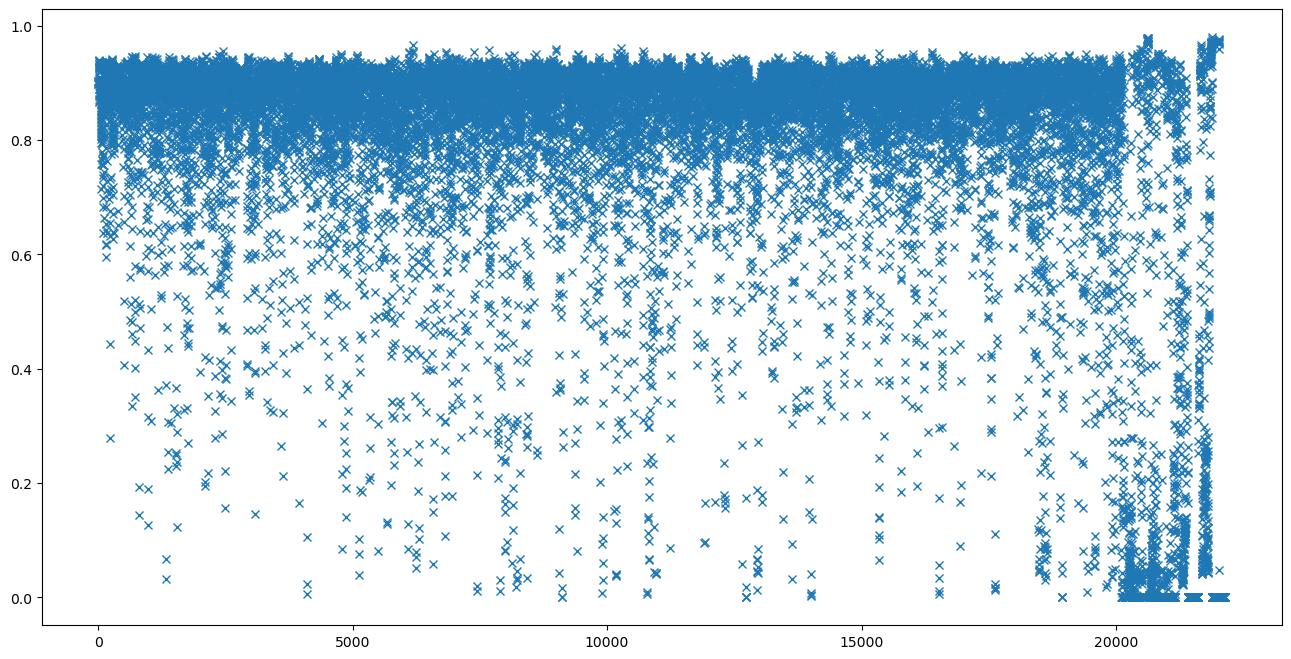

In [40]:
plt.figure(figsize=(16,8))
plt.plot(preds.detach().cpu(),'x')

In [23]:
pred_results = preds.detach().cpu()

In [24]:
idxs = np.where(pred_results[:2000] < 0.2)

In [25]:
idxs

(array([ 810,  811,  980,  981, 1336, 1337, 1551]),
 array([0, 0, 0, 0, 0, 0, 0]))

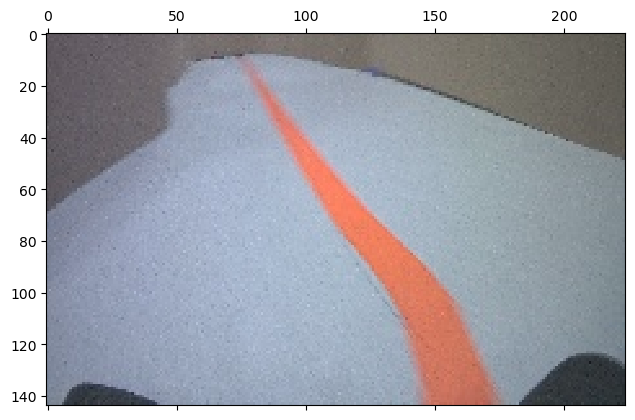

In [33]:
plt.matshow(images[1551].detach().cpu().int())

In [35]:
steers[1551].item()

-0.5631679892539978

In [36]:
torch.mean(preds[:20000])

tensor(0.8346, device='cuda:0', grad_fn=<MeanBackward0>)

In [37]:
torch.mean(preds[20000:21000])

tensor(0.3125, device='cuda:0', grad_fn=<MeanBackward0>)

In [39]:
torch.mean(preds[-1000:])

tensor(0.2527, device='cuda:0', grad_fn=<MeanBackward0>)

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [74]:
with open('runs/evolve/2026_02_02_21_34_50/1/rc.pkl', 'rb') as f:
    rc_data = pickle.load(f)

In [77]:
rc = rc_data['original']
filtered_rc = rc_data['filtered']

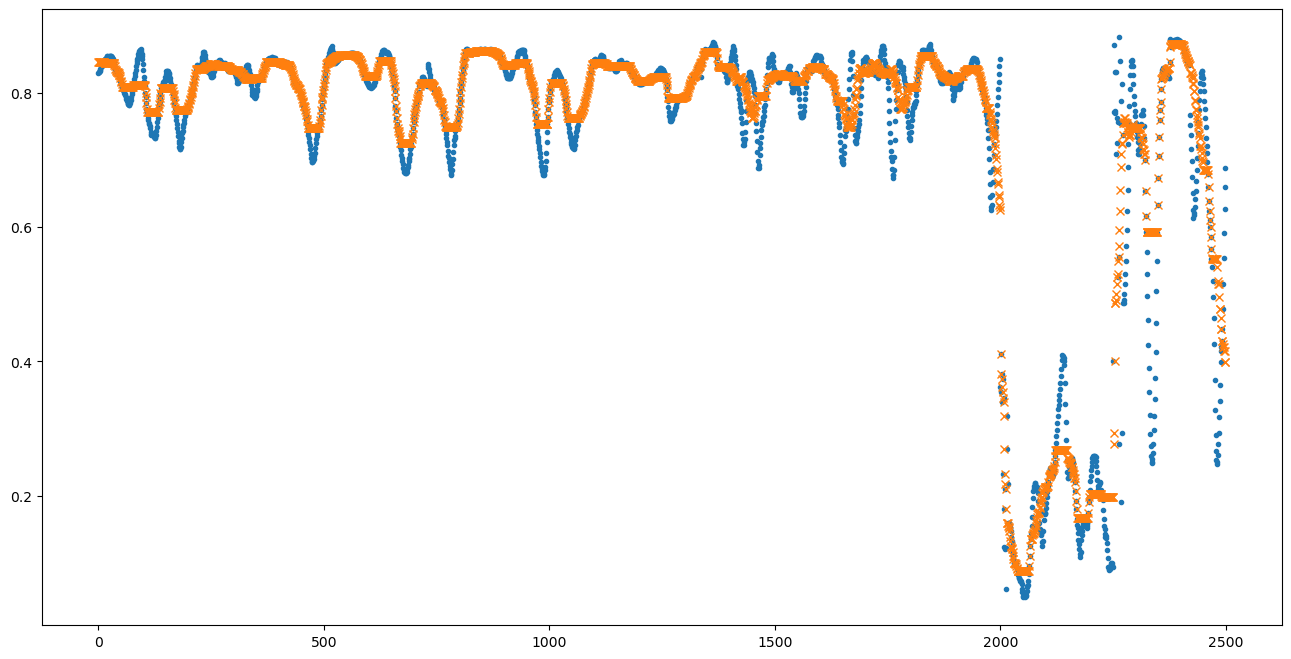

In [78]:
plt.figure(figsize=(16,8))
plt.plot(range(len(rc)), rc, '.')
plt.plot(range(len(filtered_rc)), filtered_rc,'x')

In [45]:
np.mean(rc)

np.float32(0.6931657)

In [44]:
np.std(rc)

np.float32(0.12235814)

In [42]:
len(np.where(rc < np.mean(rc) - np.std(rc))[0])

1539

# CAE Steer

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from cae_steer import CAESteer
from utils import load_data, normalize_image

In [2]:
model = CAESteer()
model.load_state_dict(torch.load('runs/cae_steer/2026_02_02_14_12_58/best.pt'))

<All keys matched successfully>

In [5]:
data = load_data({'normal' : 'data/normal.pkl', 'hitwall' : 'data/hitwall.pkl', 'zigzag' : 'data/zigzag.pkl'})

Loading training data data/normal.pkl
Loading training data data/hitwall.pkl
Loading training data data/zigzag.pkl


In [59]:
data_type = 'hitwall'

-1.0


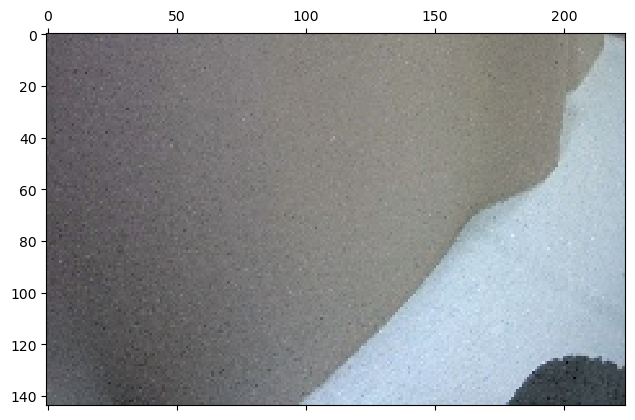

In [68]:
idx = np.random.randint(len(data[data_type]['image']))
image = data[data_type]['image'][idx]
steer = data[data_type]['steer'][idx]
print(steer)
plt.matshow(image)

In [69]:
pred_steer, latent = model(normalize_image(torch.from_numpy(image).unsqueeze(0)).permute(0,3,1,2))
pred_steer.item()

-0.6318713426589966

# CAE Steer MSE Plot

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from utils import load_data, construct_data

In [85]:
data = construct_data(load_data({
    "normal" : "data/normal.pkl",
    "hitwall" : "data/hitwall.pkl",
    "zigzag" : "data/zigzag.pkl"
}), {
    "normal" : [0,20000,1],
    "hitwall" : [0,1000,1],
    "zigzag" : [0,1000,1]
})

Loading training data data/normal.pkl
Loading training data data/hitwall.pkl
Loading training data data/zigzag.pkl
Read data normal
Read data hitwall
Read data zigzag


In [86]:
with open('runs/cae_steer/2026_02_03_21_07_46/mse_record.pkl', 'rb') as f:
    mse_data = pickle.load(f)

In [87]:
mse = mse_data[100]

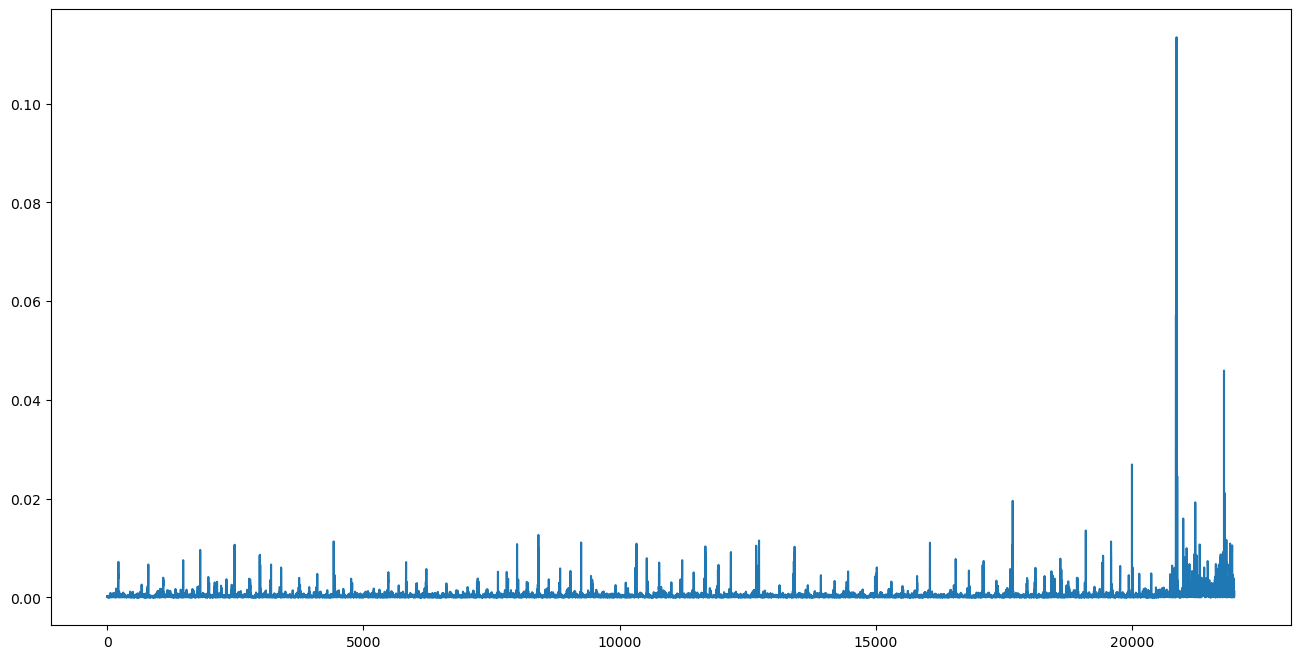

In [88]:
plt.figure(figsize=(16,8))
plt.plot(range(len(mse)), mse)

In [29]:
mse.mean()

np.float32(0.00041468476)

In [44]:
kickout_idxs = np.where(mse > mse.mean() + mse.std())[0]

In [57]:
filtered_kickout_idxs = kickout_idxs[np.where(kickout_idxs > 20000)]

In [59]:
len(filtered_kickout_idxs)

972

victim_idx = np.random.choice(filtered_kickout_idxs)
image = data['image'][victim_idx]
steer = data['steer'][victim_idx]
print(steer)
plt.imshow(image)

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [3]:
with open('runs/evolve/2026_02_04_17_40_38/confidence_data.pkl', 'rb') as f:
    conf_data = pickle.load(f)

In [4]:
mse = conf_data['mse']

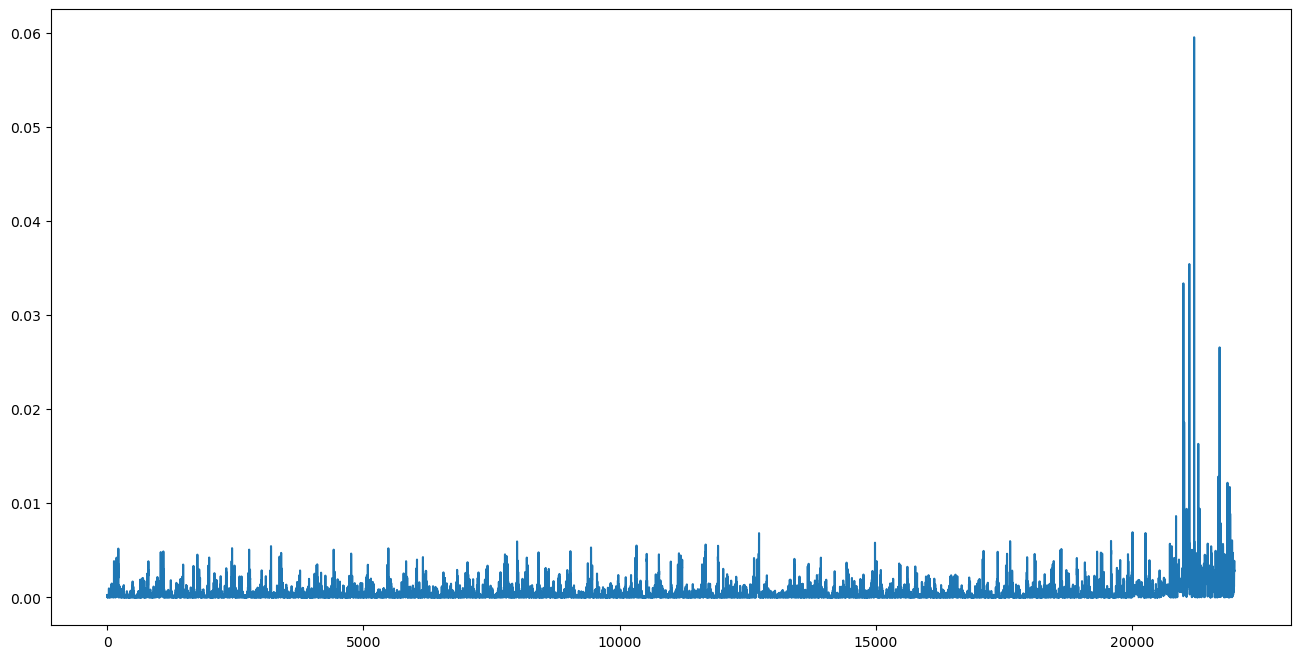

In [10]:
plt.figure(figsize=(16,8))
plt.plot(mse)

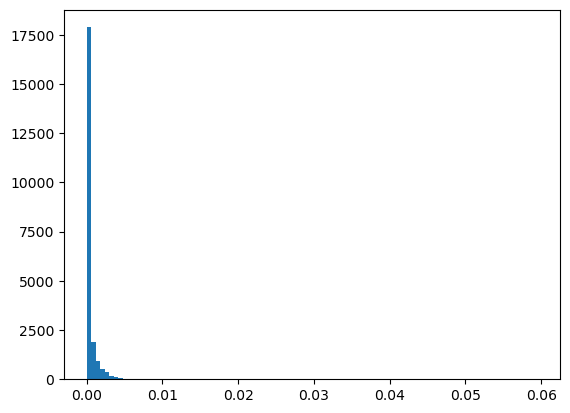

In [34]:
plt.hist(mse, bins=100);

In [35]:
pcc = conf_data['pcc']

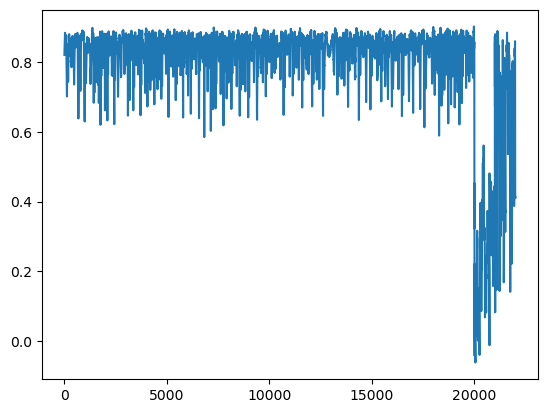

In [36]:
plt.plot(pcc)

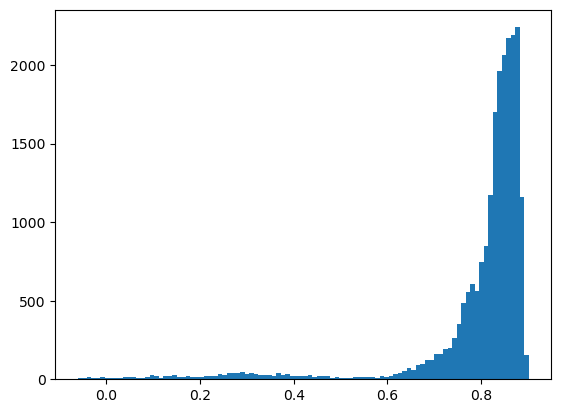

In [38]:
plt.hist(pcc, bins=100);

In [15]:
weights = conf_data['weights']

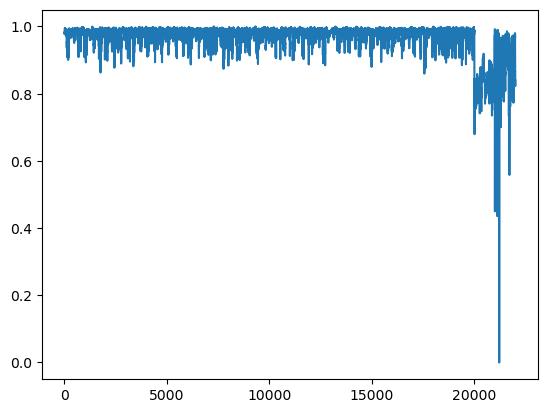

In [16]:
plt.plot(weights)

In [17]:
norm_pcc = (pcc - pcc.min()) / (pcc.max() - pcc.min())
norm_mse = (mse - mse.min()) / (mse.max() - mse.min())

In [20]:
new_weights = norm_pcc * (1 - norm_mse)

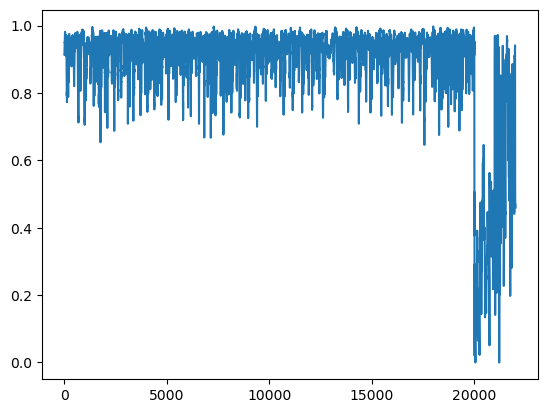

In [21]:
plt.plot(new_weights)

In [40]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [42]:
with open('runs/evolve/2026_02_05_10_50_30/critic_score.pkl', 'rb') as f:
    critic_score = pickle.load(f)